## Dependencies

brew install libjpeg <br>
conda install -c apple tensorflow-deps <br>
python -m pip install tensorflow-macos tensorflow-metal tensorflow-datasets tensorboard tensorboard_plugin_profile <br>
conda install -y matplotlib pandas jupyterlab <br>

In [2]:
import tensorflow as tf
import numpy as np
import base64
import json
import os
import glob
from PIL import Image
import io
from typing import Iterator, Tuple, List, Dict
from datetime import datetime
from tensorflow.keras.metrics import Precision, Recall
import matplotlib.pyplot as plt
import gc
import tensorflowjs as tfjs

In [3]:
tf.__version__, tfjs.__version__

('2.18.0', '4.22.0')

## Utility

In [4]:
class LazyTelemetryDataLoader:
    def __init__(self, data_dir: str, batch_size: int = 32, val_split: float = 0.2, 
                 image_size: Tuple[int, int] = (224, 224)):
        """
        Initialize lazy data loader for telemetry data
        Args:
            data_dir (str): Directory containing JSON telemetry files
            batch_size (int): Batch size for training
            val_split (float): Fraction of data to use for validation
            image_size (tuple): Target image dimensions
        """
        self.data_dir = data_dir
        self.batch_size = batch_size
        self.image_size = image_size
        self.val_split = val_split
        
        # Action mapping
        self.key_mapping = {
            "w": 0, "s": 1, "a": 2, "d": 3,
            "wd": 4, "dw": 4, "wa": 5, "aw": 5,
            "sd": 6, "ds": 6, "sa": 7, "as": 7
        }
        
        # Find and process all JSON files
        self.json_files = self._get_json_files()
        if not self.json_files:
            raise ValueError(f"No JSON files found in {data_dir}")
        print(f"Found {len(self.json_files)} JSON files")
        
        # Merge all telemetry files
        self.merged_data = self._merge_telemetry_files()

        # Get total number of samples
        self.total_samples = len(self.merged_data['actions'])
        self.val_samples = int(self.total_samples * val_split)
        self.train_samples = self.total_samples - self.val_samples
        
        # Create train/val indices
        indices = np.arange(self.total_samples)
        np.random.shuffle(indices)  # Shuffle all indices
        split_idx = int(self.total_samples * (1 - val_split))
        self.train_indices = indices[:split_idx]
        self.val_indices = indices[split_idx:]
        
        # Calculate steps per epoch
        self.train_steps = len(self.train_indices) // batch_size
        self.val_steps = len(self.val_indices) // batch_size

        print(f"Total samples: {self.total_samples}")
        print(f"Training samples: {self.train_samples}")
        print(f"Validation samples: {self.val_samples}")
        print(f"Training steps per epoch: {self.train_steps}")
        print(f"Validation steps per epoch: {self.val_steps}")

    def _get_json_files(self) -> List[str]:
        """Get all JSON files in directory and subdirectories"""
        return glob.glob(os.path.join(self.data_dir, "**/*.json"), recursive=True)

    def _merge_telemetry_files(self) -> str:
        """Merge all telemetry files into one"""
        print("Merging telemetry files...")
        
        # Initialize merged data structure
        merged_data = {
            "actions": [],
            "metadata": {
                "total_files": len(self.json_files),
                "merge_date": datetime.now().isoformat(),
                "successful_runs": 0,
                "failed_runs": 0
            }
        }
        
        # Process each file
        for file_path in self.json_files:
            try:
                with open(file_path, 'r') as f:
                    data = json.load(f)
                    
                # Validate file structure
                if not isinstance(data, dict) or "actions" not in data:
                    print(f"Skipping invalid file: {file_path}")
                    merged_data["metadata"]["failed_runs"] += 1
                    continue
                    
                # Add file metadata
                if data.get("completed", False):
                    merged_data["metadata"]["successful_runs"] += 1
                else:
                    merged_data["metadata"]["failed_runs"] += 1
                
                # Merge actions
                merged_data["actions"].extend(data["actions"])
                
            except Exception as e:
                print(f"Error processing file {file_path}: {str(e)}")
                merged_data["metadata"]["failed_runs"] += 1
                continue
                    
        print(f"Total actions: {len(merged_data['actions'])}")
        print(f"Successful runs: {merged_data['metadata']['successful_runs']}")
        print(f"Failed runs: {merged_data['metadata']['failed_runs']}")

        return merged_data

    def _process_action(self, action: dict) -> int:
        """Convert action to label"""
        try:
            inputs = action.get('keypressInputs', [])
            if not inputs:
                return 0
            
            last_input = inputs[-1]
            clean_input = last_input.replace("Arrow", "").replace("Shift", "")
            clean_input = clean_input.replace("Up", "w").replace("Down", "s")
            clean_input = clean_input.replace("Left", "a").replace("Right", "d")
            clean_input = clean_input.lower()
            
            clean_input = clean_input.replace("sw", "w").replace("ws", "s")
            clean_input = clean_input.replace("ad", "d").replace("da", "a")
            
            return self.key_mapping.get(clean_input, 0)
        except Exception as e:
            print(f"Error processing action: {e}")
            return 0

    def _process_image(self, base64_string: str) -> np.ndarray:
        """Convert base64 string to numpy array with exact dimensions"""
        try:
            if ',' in base64_string:
                base64_string = base64_string.split(',')[1]
            
            # Decode base64 to image
            img = Image.open(io.BytesIO(base64.b64decode(base64_string)))
            
            if img.mode != 'RGB':
                img = img.convert('RGB')
            
            # Get current dimensions
            width, height = img.size
            target_width, target_height = self.image_size
            
            # Calculate dimensions to maintain aspect ratio
            if width / height > target_width / target_height:
                # Image is wider than target
                new_width = int(height * target_width / target_height)
                left = (width - new_width) // 2
                img = img.crop((left, 0, left + new_width, height))
            else:
                # Image is taller than target
                new_height = int(width * target_height / target_width)
                top = (height - new_height) // 2
                img = img.crop((0, top, width, top + new_height))
            
            # Resize to exact dimensions
            img = img.resize(self.image_size, Image.Resampling.BILINEAR)
            
            # Convert to numpy array efficiently
            img_array = np.asarray(img, dtype=np.float32) / 255.0
            img_array = np.mean(img_array, axis=-1)
            
            return img_array
        except Exception as e:
            print(f"Error processing image: {e}")
            return None

    def data_generator(self, validation: bool = False) -> Iterator[Tuple[np.ndarray, np.ndarray]]:
        """Generator that yields batches of (images, labels)"""
        indices = self.val_indices if validation else self.train_indices
        steps = self.val_steps if validation else self.train_steps
        
        while True:  # Loop forever for training
            if not validation:
                np.random.shuffle(indices)  # Shuffle only training data
            
            # Generate batches
            for step in range(steps):
                start_idx = step * self.batch_size
                end_idx = start_idx + self.batch_size
                batch_indices = indices[start_idx:end_idx]
                
                # Pre-allocate arrays for batch
                batch_images = np.empty((self.batch_size, *self.image_size), dtype=np.float32)
                batch_labels = np.empty(self.batch_size, dtype=np.int32)
                
                # Fill the batch
                for i, idx in enumerate(batch_indices):
                    action = self.merged_data['actions'][idx]
                    if 'screenshotBase64' in action:
                        img = self._process_image(action['screenshotBase64'])
                        if img is not None:
                            batch_images[i] = img
                            batch_labels[i] = self._process_action(action)
                
                #batch_images = np.expand_dims(batch_images, axis=-1)
                yield batch_images, batch_labels

    def get_dataset(self, validation: bool = False) -> tf.data.Dataset:
        """Create TensorFlow dataset"""
        # Create dataset from generator with output shapes
        dataset = tf.data.Dataset.from_generator(
            lambda: self.data_generator(validation),
            output_signature=(
                tf.TensorSpec(shape=(self.batch_size, *self.image_size), dtype=tf.float32),
                tf.TensorSpec(shape=(self.batch_size,), dtype=tf.int32)
            )
        )
        
        dataset = dataset.map(
            lambda x, y: (tf.expand_dims(x, axis=-1), y),
            num_parallel_calls=tf.data.AUTOTUNE
        )
        
        if not validation:
            # Add augmentation for training
            dataset = dataset.map(
                self._augment,
                num_parallel_calls=tf.data.AUTOTUNE
            )
        
        # Only prefetch since batching is handled by generator
        dataset = dataset.prefetch(tf.data.AUTOTUNE)
        
        return dataset

    def _augment(self, image: tf.Tensor, label: tf.Tensor) -> Tuple[tf.Tensor, tf.Tensor]:
        """Apply data augmentation"""
        image = tf.image.random_brightness(image, 0.2)
        image = tf.image.random_contrast(image, 0.8, 1.2)
        image = tf.clip_by_value(image, 0, 1)
        return image, label
    
    def get_training_parameters(self):
        """Get parameters needed for training"""
        return {
            'steps_per_epoch': self.train_steps,
            'validation_steps': self.val_steps
        }

In [5]:
# Create a custom F1 Score metric
class F1Score(tf.keras.metrics.Metric):
    def __init__(self, name='f1_score', **kwargs):
        super().__init__(name=name, **kwargs)
        self.precision = Precision()
        self.recall = Recall()
        
    def update_state(self, y_true, y_pred, sample_weight=None):
        # Convert probabilities to class predictions
        y_pred = tf.argmax(y_pred, axis=1)
        y_true = tf.cast(y_true, tf.int32)
        
        self.precision.update_state(y_true, y_pred, sample_weight)
        self.recall.update_state(y_true, y_pred, sample_weight)
    
    def result(self):
        p = self.precision.result()
        r = self.recall.result()
        return 2 * ((p * r) / (p + r + tf.keras.backend.epsilon()))
    
    def reset_state(self):
        self.precision.reset_state()
        self.recall.reset_state()

In [9]:
def save_model_for_web(model, save_dir: str = "web_model", weight_shard_byte_size=1024*1024*1):
    """
    Save model in TensorFlow.js format
    Args:
        model: Trained TensorFlow model
        save_dir: Directory to save the model
    """
    try:
        # Create directory if it doesn't exist
        os.makedirs(save_dir, exist_ok=True)
        
        # Save model in TF.js format
        tfjs.converters.save_keras_model(model, 
                                         save_dir, 
                                         weight_shard_byte_size=weight_shard_byte_size)
        
        # Generate metadata
        metadata = {
            "inputShape": model.input_shape[1:],  # Remove batch dimension
            "outputShape": model.output_shape[1:],
            "meanImage": 0.0,  # Add preprocessing values if used
            "stdImage": 255.0,
            "labels": ["forward", "backward", "left", "right", 
                      "forward_right", "forward_left", 
                      "backward_right", "backward_left"]
        }
        
        # Save metadata
        with open(os.path.join(save_dir, "metadata.json"), "w") as f:
            json.dump(metadata, f)
            
        print(f"Model saved in TF.js format at: {save_dir}")
        print("Files saved:")
        for file in os.listdir(save_dir):
            print(f"- {file}")
            
    except Exception as e:
        print(f"Error saving model: {str(e)}")

## Model

In [7]:
def create_cnn_model(input_dims, output_dim, dropout_rate=0.5):
    """
    Creates a simple CNN model using TensorFlow layers
    Returns:
        tf.keras.Model: Compiled CNN model
    """

    model = tf.keras.Sequential([
        tf.keras.layers.Input(shape=input_dims),
        
        tf.keras.layers.Conv2D(filters=32, kernel_size=(3, 3), activation=tf.nn.relu, padding='same'),
        tf.keras.layers.MaxPooling2D(pool_size=(2, 2)),
        tf.keras.layers.BatchNormalization(),
        
        tf.keras.layers.Conv2D(filters=64, kernel_size=(3, 3), activation=tf.nn.relu, padding='same'),
        tf.keras.layers.MaxPooling2D(pool_size=(2, 2)),
        tf.keras.layers.BatchNormalization(),
        
        tf.keras.layers.Conv2D(filters=128, kernel_size=(3, 3), activation=tf.nn.relu, padding='same'),
        tf.keras.layers.MaxPooling2D(pool_size=(2, 2)),
        tf.keras.layers.BatchNormalization(),

        tf.keras.layers.Conv2D(filters=256, kernel_size=(3, 3), activation=tf.nn.relu, padding='same'),
        tf.keras.layers.MaxPooling2D(pool_size=(2, 2)),
        tf.keras.layers.BatchNormalization(),
        
        tf.keras.layers.Flatten(),
        tf.keras.layers.Dropout(dropout_rate),
        tf.keras.layers.Dense(units=128, activation=tf.nn.relu),
        tf.keras.layers.Dense(units=output_dim, activation=tf.nn.softmax)
    ])
    
    model.compile(optimizer=tf.optimizers.Adam(learning_rate=0.001), 
                  loss=tf.losses.SparseCategoricalCrossentropy(), 
                  metrics=[F1Score()])
    
    return model

In [8]:
model = create_cnn_model((224, 224, 1), 4)
model.summary()

I0000 00:00:1741933868.458096   11097 pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
I0000 00:00:1741933868.458164   11097 pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 224, 224, 32)   │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 112, 112, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 56, 56, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 28, 28, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 28, 28, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 14, 14, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 14, 14, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 50176)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 50176)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     6,422,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,812,932 (25.99 MB)

 Trainable params: 6,811,972 (25.99 MB)

 Non-trainable params: 960 (3.75 KB)

## Training


In [7]:
# Initialize with directory containing JSON files
data_loader = LazyTelemetryDataLoader(
    data_dir='./Dataset',
    batch_size=32
)

# Get datasets
train_ds = data_loader.get_dataset(validation=False)
val_ds = data_loader.get_dataset(validation=True)

Found 54 JSON files
Merging telemetry files...
Total actions: 54640
Successful runs: 6
Failed runs: 48
Total samples: 54640
Training samples: 43712
Validation samples: 10928
Training steps per epoch: 1366
Validation steps per epoch: 341


In [8]:
# Training parameters
epochs = 20

callbacks = [
    # Early Stopping
    tf.keras.callbacks.EarlyStopping(monitor='val_f1_score',patience=10,restore_best_weights=True,mode='min'),
    # Learning Rate Reduction
    tf.keras.callbacks.ReduceLROnPlateau(monitor='val_loss',factor=0.2,patience=5, min_lr=1e-6, mode='min')
]

# Get training parameters
params = data_loader.get_training_parameters()

# Train model
history = model.fit(train_ds,
          epochs=epochs,
          steps_per_epoch=params['steps_per_epoch'],
          validation_data=val_ds,
          validation_steps=params['validation_steps'],
          callbacks=callbacks)

Epoch 1/20
1366/1366 ━━━━━━━━━━━━━━━━━━━━ 259s 188ms/step - f1_score: 0.4509 - loss: 12.5833 - val_f1_score: 0.5534 - val_loss: 13.4455 - learning_rate: 0.0010
Epoch 2/20
1366/1366 ━━━━━━━━━━━━━━━━━━━━ 252s 184ms/step - f1_score: 0.5375 - loss: 15.8236 - val_f1_score: 0.6034 - val_loss: 16.3412 - learning_rate: 0.0010
Epoch 3/20
1366/1366 ━━━━━━━━━━━━━━━━━━━━ 258s 189ms/step - f1_score: 0.5644 - loss: 25.4526 - val_f1_score: 0.6035 - val_loss: 53.4008 - learning_rate: 0.0010
Epoch 4/20
1366/1366 ━━━━━━━━━━━━━━━━━━━━ 255s 187ms/step - f1_score: 0.5741 - loss: 35.5278 - val_f1_score: 0.5076 - val_loss: 68.8088 - learning_rate: 0.0010
Epoch 5/20
1366/1366 ━━━━━━━━━━━━━━━━━━━━ 246s 180ms/step - f1_score: 0.5777 - loss: 47.6026 - val_f1_score: 0.4917 - val_loss: 52.4451 - learning_rate: 0.0010
Epoch 6/20
1366/1366 ━━━━━━━━━━━━━━━━━━━━ 239s 175ms/step - f1_score: 0.5830 - loss: 60.7074 - val_f1_score: 0.5948 - val_loss: 87.8886 - learning_rate: 0.0010
Epoch 7/20
1366/1366 ━━━━━━━━━━━━━━━━━━━

In [9]:
# Print final metrics
final_train_loss, final_train_f1 = history.history['loss'][-1], history.history['f1_score'][-1]
final_val_loss, final_val_f1 = history.history['val_loss'][-1], history.history['val_f1_score'][-1]

print(f"\nFinal Training Metrics:\nLoss: {final_train_loss:.4f}\nF1 Score: {final_train_f1:.4f}")
print(f"\nFinal Validation Metrics:\nLoss: {final_val_loss:.4f}\nF1 Score: {final_val_f1:.4f}")


Final Training Metrics:
Loss: 14.3950
F1 Score: 0.7082

Final Validation Metrics:
Loss: 8.7921
F1 Score: 0.7598


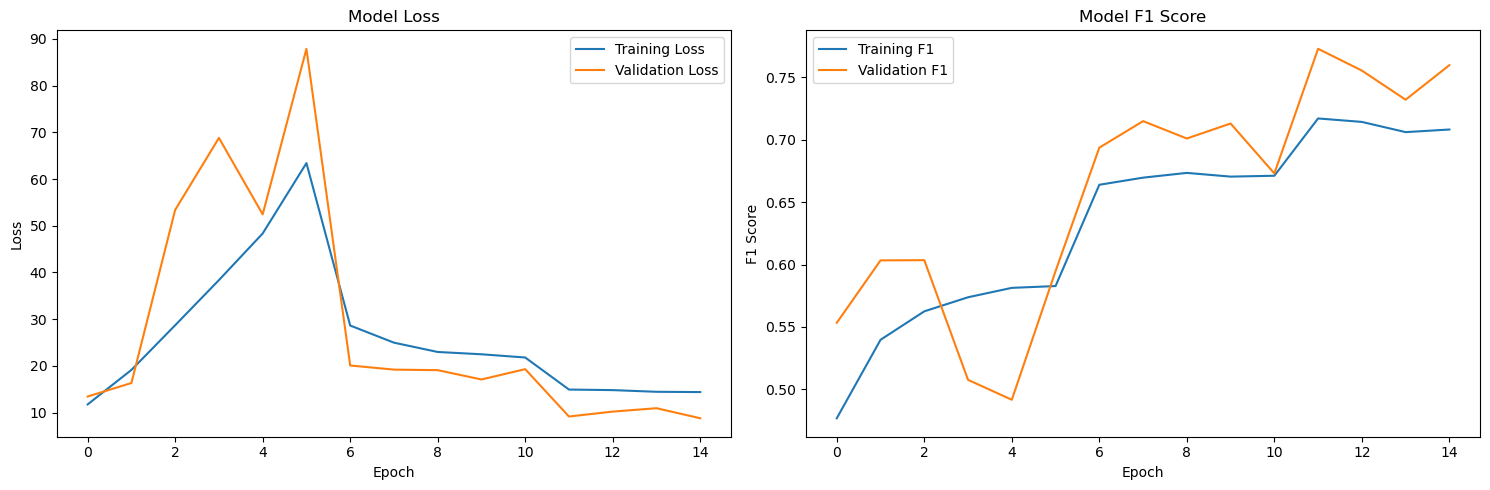

In [10]:
# Plot training history
plt.figure(figsize=(15, 5))

# Plot loss
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

# Plot F1 Score
plt.subplot(1, 2, 2)
plt.plot(history.history['f1_score'], label='Training F1')
plt.plot(history.history['val_f1_score'], label='Validation F1')
plt.title('Model F1 Score')
plt.xlabel('Epoch')
plt.ylabel('F1 Score')
plt.legend()

plt.tight_layout()
plt.show()

In [10]:
save_model_for_web(model, './models/my_model_web_v3')

Error saving model: save_keras_model() got an unexpected keyword argument 'weights_manifest_mode'


In [11]:
tfjs.converters.save_keras_model?

Signature:
tfjs.converters.save_keras_model(
    model,
    artifacts_dir,
    quantization_dtype_map=None,
    weight_shard_size_bytes=4194304,
    metadata=None,
)
Docstring:
Save a Keras model and its weights in TensorFlow.js format.

Args:
  model: An instance of `keras.Model`.
  artifacts_dir: The directory in which the artifacts will be saved.
    The artifacts to be saved include:
      - model.json: A JSON representing the model. It has the following
        fields:
        - 'modelTopology': A JSON object describing the topology of the model,
          along with additional information such as training. It is obtained
          through calling `model.save()`.
        - 'weightsManifest': A TensorFlow.js-format JSON manifest for the
          model's weights.
      - files containing weight values in groups, with the file name pattern
        group(\d+)-shard(\d+)of(\d+).
    If the directory does not exist, this function will attempt to create it.
  quantization_dtype_map: (Op